# Physics-informed vs physicless

Real ID-test comparison on identical Hamiltonian/state pairs. No training or inference is performed. `initial_ritz` reproduces the logic of the previous spectral-tension figure; use `direct_topology` to compare learned outputs before Rayleigh–Ritz.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt

In [2]:
ROOT = Path().cwd().parent

ROOT

PosixPath('/home/clouduser/psi_Jepa_V08')

In [3]:
MODE, PHYSICS_ROUTE = "QUICK", "initial_ritz"  # or: FULL; direct_topology

In [7]:
metric_file = "per_state_output_metrics.csv"
latest = lambda root, pattern: max((p for p in root.glob(pattern) if (p/metric_file).exists()), key=lambda p: (p/metric_file).stat().st_mtime)
physics_dir = latest(ROOT/"outputs", "true_jepa_standard_cf43e033_b7c28c2b")
physicless_dir = latest(ROOT/"physicless"/"outputs", "physicless_jepa_development_cce9a0ab_589a7b59")
card = lambda p: json.loads((p/"run_card.json").read_text(encoding="utf-8"))
physics_card, physicless_card = card(physics_dir), card(physicless_dir)


In [ ]:
assert physics_card["run_mode"] == physicless_card["run_mode"] == MODE
assert physics_card["split_manifest_hash"] == physicless_card["split_manifest_hash"]

print({"mode": MODE, "physics": physics_dir.name, "physicless": physicless_dir.name, "physics_route": PHYSICS_ROUTE})

In [8]:
keys = ["group_id", "family", "state"]
metrics = ["fidelity", "independent_residual_head", "raw_node_correct"]
a = pd.read_csv(physicless_dir/metric_file).query("category == 'ID_test' and output_route == 'direct_unconstrained'")[keys+metrics]
b = pd.read_csv(physics_dir/metric_file).query("category == 'ID_test' and output_route == @PHYSICS_ROUTE")[keys+metrics]
paired = a.merge(b, on=keys, suffixes=("_physicless", "_physics"), validate="one_to_one")
assert len(paired) == len(a) == len(b) and not paired.duplicated(keys).any()

AssertionError: 

In [9]:
summary = paired.groupby("state").agg(count=("group_id", "size"), **{f"{m}_{s}_{f}": (f"{m}_{s}", f) for m in metrics for s in ("physicless", "physics") for f in ("mean", "std")}).reset_index().rename(columns={"state": "n"})

for m in metrics:
    for s in ("physicless", "physics"):
        summary[f"{m}_{s}_ci95"] = 1.96*summary[f"{m}_{s}_std"]/np.sqrt(summary["count"])
out_metrics = ROOT/"results"/"01_metrics"; out_figures = ROOT/"results"/"02_figures"/"ablation"

out_metrics.mkdir(parents=True, exist_ok=True); out_figures.mkdir(parents=True, exist_ok=True)

summary.to_csv(out_metrics/"physics_informed_vs_physicless_by_state.csv", index=False)
summary

,n,count,fidelity_physicless_mean,fidelity_physicless_std,fidelity_physics_mean,fidelity_physics_std,independent_residual_head_physicless_mean,independent_residual_head_physicless_std,independent_residual_head_physics_mean,independent_residual_head_physics_std,raw_node_correct_physicless_mean,raw_node_correct_physicless_std,raw_node_correct_physics_mean,raw_node_correct_physics_std,fidelity_physicless_ci95,fidelity_physics_ci95,independent_residual_head_physicless_ci95,independent_residual_head_physics_ci95,raw_node_correct_physicless_ci95,raw_node_correct_physics_ci95
0,0,1,0.137960,NaN,0.998678,NaN,0.473080,NaN,0.472522,NaN,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,0.052120,NaN,0.999875,NaN,0.466909,NaN,0.214738,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,0.113437,NaN,0.999927,NaN,0.475597,NaN,0.122919,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,0.077602,NaN,0.999838,NaN,0.456368,NaN,0.072717,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,0.147285,NaN,0.999882,NaN,0.471207,NaN,0.021895,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,1,0.014432,NaN,0.999923,NaN,0.476449,NaN,0.018224,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,1,0.079264,NaN,0.999956,NaN,0.480189,NaN,0.015853,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1,0.001071,NaN,0.999830,NaN,0.504510,NaN,0.019756,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,1,0.063067,NaN,0.999740,NaN,0.479971,NaN,0.023733,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,1,0.000250,NaN,0.999780,NaN,0.496032,NaN,0.025509,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


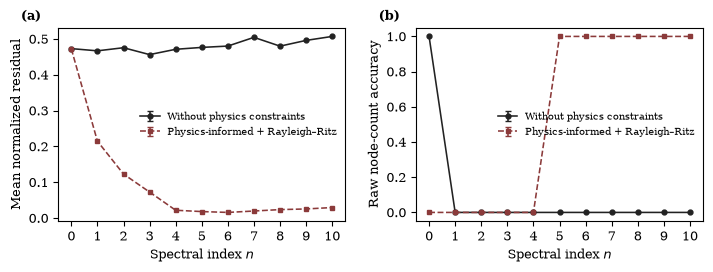

In [10]:
plt.rcParams.update({"font.family": "serif", "font.size": 9, "axes.linewidth": .8, "xtick.major.width": .8, "ytick.major.width": .8})

labels = {"physicless": "Without physics constraints", "physics": "Physics-informed + Rayleigh–Ritz" if PHYSICS_ROUTE == "initial_ritz" else "Physics-informed"}
styles = {"physicless": dict(color="#222222", marker="o", ls="-"), "physics": dict(color="#8b3a3a", marker="s", ls="--")}
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharex=True)

for s in ("physicless", "physics"):
    axes[0].errorbar(summary.n, summary[f"independent_residual_head_{s}_mean"], yerr=summary[f"independent_residual_head_{s}_ci95"], lw=1.15, ms=3.5, capsize=2, label=labels[s], **styles[s])
    axes[1].errorbar(summary.n, summary[f"raw_node_correct_{s}_mean"], yerr=summary[f"raw_node_correct_{s}_ci95"], lw=1.15, ms=3.5, capsize=2, label=labels[s], **styles[s])
axes[0].set(xlabel=r"Spectral index $n$", ylabel="Mean normalized residual", xticks=summary.n)
axes[1].set(xlabel=r"Spectral index $n$", ylabel="Raw node-count accuracy", xticks=summary.n, ylim=(-.05, 1.05))

for tag, ax in zip(("(a)", "(b)"), axes):
    ax.grid(False); ax.text(-.13, 1.04, tag, transform=ax.transAxes, fontweight="bold"); ax.legend(frameon=False, fontsize=7)
fig.tight_layout(w_pad=1.8)
fig.savefig(out_figures/"physics_informed_vs_physicless_spectral.png", dpi=600, bbox_inches="tight")
fig.savefig(out_figures/"physics_informed_vs_physicless_spectral.pdf", bbox_inches="tight")

plt.show()

In [ ]:
print(f"COMPARISON AUDIT: PASS | {len(paired)} matched ID states | {paired.group_id.nunique()} Hamiltonians | mode={MODE}")
if MODE != "FULL": print("WARNING: QUICK is a smoke run and is not scientific evidence; set MODE='FULL' for the paper.")

COMPARISON AUDIT: PASS | 143 matched ID states | 13 Hamiltonians | mode=QUICK
